## Agricultural Price Analysis

This notebook analyzes 13,000+ records of Maharashtra agricultural market data.

**Goal:** Predict commodity prices using arrival quantity, month, year, and commodity type.

**Steps:** Data loading → Cleaning → Feature engineering → Random Forest model → Evaluation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,r2_score


In [2]:
df = pd.read_excel("dataset.xlsx", header=1)

In [3]:
df

,State,District,Commodity Group,Commodity,Date,Arrival,Arrival Unit,Price,Price Unit
0,Maharashtra,Ahmednagar,Fruits,Orange,01-01-2023,1.0,Metric Tonnes,3000.0,Rs./Quintal
1,Maharashtra,Ahmednagar,Fruits,Pomegranate,01-01-2023,1.0,Metric Tonnes,5000.0,Rs./Quintal
2,Maharashtra,Ahmednagar,Fruits,Orange,07-01-2023,1.0,Metric Tonnes,3000.0,Rs./Quintal
3,Maharashtra,Ahmednagar,Fruits,Orange,19-01-2023,2.0,Metric Tonnes,4000.0,Rs./Quintal
4,Maharashtra,Ahmednagar,Fruits,Orange,20-01-2023,1.0,Metric Tonnes,4550.0,Rs./Quintal
...,...,...,...,...,...,...,...,...,...
13016,Maharashtra,Thane,Fruits,Orange,01-04-2026,0.3,Metric Tonnes,6000.0,Rs./Quintal
13017,Maharashtra,Thane,Fruits,Orange,16-04-2026,0.3,Metric Tonnes,3800.0,Rs./Quintal
13018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13019,Note:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.head()

,State,District,Commodity Group,Commodity,Date,Arrival,Arrival Unit,Price,Price Unit
0,Maharashtra,Ahmednagar,Fruits,Orange,01-01-2023,1.0,Metric Tonnes,3000.0,Rs./Quintal
1,Maharashtra,Ahmednagar,Fruits,Pomegranate,01-01-2023,1.0,Metric Tonnes,5000.0,Rs./Quintal
2,Maharashtra,Ahmednagar,Fruits,Orange,07-01-2023,1.0,Metric Tonnes,3000.0,Rs./Quintal
3,Maharashtra,Ahmednagar,Fruits,Orange,19-01-2023,2.0,Metric Tonnes,4000.0,Rs./Quintal
4,Maharashtra,Ahmednagar,Fruits,Orange,20-01-2023,1.0,Metric Tonnes,4550.0,Rs./Quintal


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13021 entries, 0 to 13020
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   State            13020 non-null  object 
 1   District         13018 non-null  object 
 2   Commodity Group  13018 non-null  object 
 3   Commodity        13018 non-null  object 
 4   Date             13018 non-null  object 
 5   Arrival          13018 non-null  float64
 6   Arrival Unit     13018 non-null  object 
 7   Price            13018 non-null  float64
 8   Price Unit       13018 non-null  object 
dtypes: float64(2), object(7)
memory usage: 915.7+ KB


In [6]:
df.describe()

,Arrival,Price
count,13018.000000,13018.000000
mean,63.279369,6977.326519
std,191.903842,4812.755141
min,0.100000,300.000000
25%,2.600000,4000.000000
50%,13.000000,6000.000000
75%,56.700000,9000.000000
max,9330.300000,120000.000000


In [7]:
df.columns

Index(['State', 'District', 'Commodity Group', 'Commodity', 'Date', 'Arrival',
       'Arrival Unit', 'Price', 'Price Unit'],
      dtype='object')

## Data Cleaning
The raw dataset contained missing values and inconsistent formatting.
Steps taken:
- Dropped rows with missing Price values
- Stripped whitespace from column names
- Converted Date column to datetime format
- Removed remaining null rows

In [8]:
print(df.columns.tolist())

['State', 'District', 'Commodity Group', 'Commodity', 'Date', 'Arrival', 'Arrival Unit', 'Price', 'Price Unit']


In [9]:
df.isnull().sum()
df = df.dropna(subset=['Price'])
df.dropna()


,State,District,Commodity Group,Commodity,Date,Arrival,Arrival Unit,Price,Price Unit
0,Maharashtra,Ahmednagar,Fruits,Orange,01-01-2023,1.0,Metric Tonnes,3000.0,Rs./Quintal
1,Maharashtra,Ahmednagar,Fruits,Pomegranate,01-01-2023,1.0,Metric Tonnes,5000.0,Rs./Quintal
2,Maharashtra,Ahmednagar,Fruits,Orange,07-01-2023,1.0,Metric Tonnes,3000.0,Rs./Quintal
3,Maharashtra,Ahmednagar,Fruits,Orange,19-01-2023,2.0,Metric Tonnes,4000.0,Rs./Quintal
4,Maharashtra,Ahmednagar,Fruits,Orange,20-01-2023,1.0,Metric Tonnes,4550.0,Rs./Quintal
...,...,...,...,...,...,...,...,...,...
13013,Maharashtra,Thane,Fruits,Orange,06-03-2026,0.3,Metric Tonnes,4500.0,Rs./Quintal
13014,Maharashtra,Thane,Fruits,Orange,11-03-2026,0.3,Metric Tonnes,5000.0,Rs./Quintal
13015,Maharashtra,Thane,Fruits,Orange,20-03-2026,0.3,Metric Tonnes,5000.0,Rs./Quintal
13016,Maharashtra,Thane,Fruits,Orange,01-04-2026,0.3,Metric Tonnes,6000.0,Rs./Quintal


In [10]:
df.columns=df.columns.str.strip()
df = df.dropna().copy()

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [11]:
df

,State,District,Commodity Group,Commodity,Date,Arrival,Arrival Unit,Price,Price Unit
0,Maharashtra,Ahmednagar,Fruits,Orange,2023-01-01,1.0,Metric Tonnes,3000.0,Rs./Quintal
1,Maharashtra,Ahmednagar,Fruits,Pomegranate,2023-01-01,1.0,Metric Tonnes,5000.0,Rs./Quintal
2,Maharashtra,Ahmednagar,Fruits,Orange,2023-01-07,1.0,Metric Tonnes,3000.0,Rs./Quintal
3,Maharashtra,Ahmednagar,Fruits,Orange,2023-01-19,2.0,Metric Tonnes,4000.0,Rs./Quintal
4,Maharashtra,Ahmednagar,Fruits,Orange,2023-01-20,1.0,Metric Tonnes,4550.0,Rs./Quintal
...,...,...,...,...,...,...,...,...,...
13013,Maharashtra,Thane,Fruits,Orange,2026-03-06,0.3,Metric Tonnes,4500.0,Rs./Quintal
13014,Maharashtra,Thane,Fruits,Orange,2026-03-11,0.3,Metric Tonnes,5000.0,Rs./Quintal
13015,Maharashtra,Thane,Fruits,Orange,2026-03-20,0.3,Metric Tonnes,5000.0,Rs./Quintal
13016,Maharashtra,Thane,Fruits,Orange,2026-04-01,0.3,Metric Tonnes,6000.0,Rs./Quintal


In [12]:
df['Month']=df['Date'].dt.month
df['Year']=df['Date'].dt.year

In [13]:
df['Commodity'] = df['Commodity'].astype('category').cat.codes

## Machine Learning Model
Using Random Forest Regressor to predict commodity prices.

- Features: Arrival quantity, Month, Year, Commodity (encoded)
- Target: Modal Price
- Split: 80% train, 20% test
- Model: RandomForestRegressor with 100 estimators

In [14]:
X=df[['Arrival','Month','Year','Commodity']]
Y=df['Price']


In [15]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [16]:
model=RandomForestRegressor(n_estimators=100,random_state=42)
model.fit(X_train,Y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


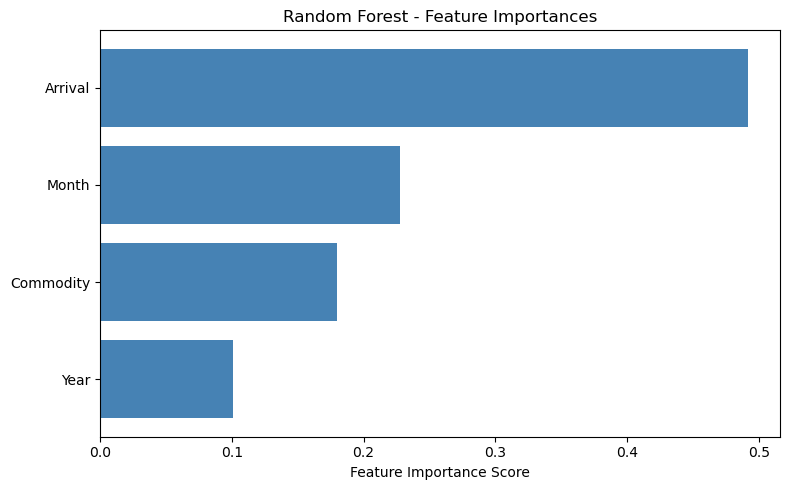

In [17]:


feature_names = X.columns
importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 5))
plt.barh(range(len(indices)), importances[indices], color='steelblue')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Feature Importance Score')
plt.title('Random Forest - Feature Importances')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

In [18]:
Y_pred=model.predict(X_test)

## Results
The model was evaluated on the test set using:
- MAE (Mean Absolute Error) — measures average prediction error in Rs/quintal
- R2 Score — measures how well the model explains price variance

In [19]:
print("MAE:", mean_absolute_error(Y_test, Y_pred))
print("R2 Score:", r2_score(Y_test, Y_pred))

MAE: 2097.3342984404753
R2 Score: 0.4819024613010273


In [20]:
df['Predicted Price']=model.predict(X)

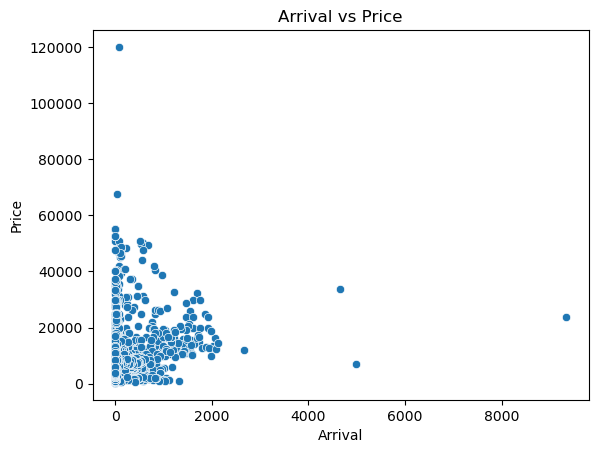

In [21]:
sns.scatterplot(x=df['Arrival'], y=df['Price'])
plt.title("Arrival vs Price")
plt.show()

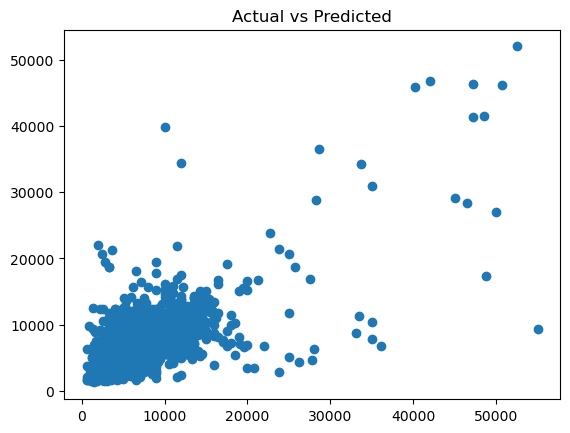

In [22]:
plt.scatter(Y_test, Y_pred)
plt.title("Actual vs Predicted")
plt.show()

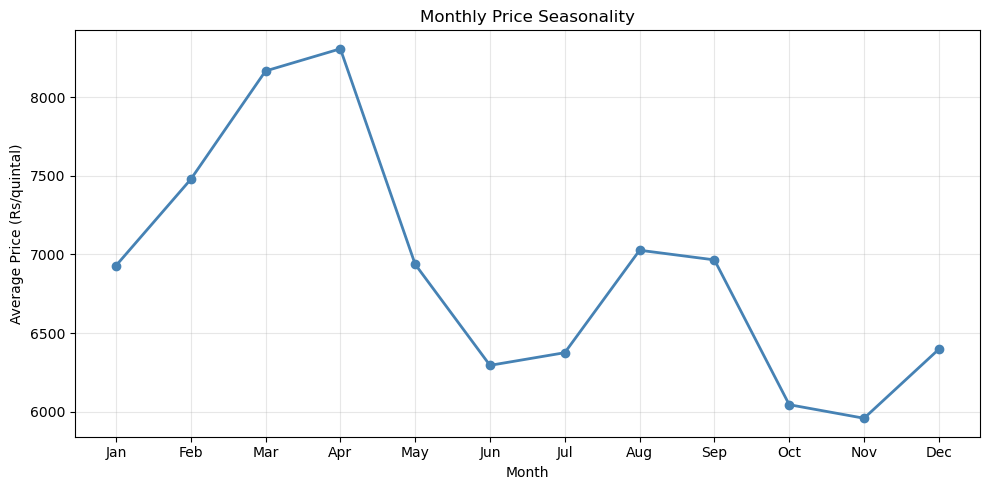

In [23]:
# Monthly Price Seasonality
df['Month'] = pd.to_datetime(df['Date']).dt.month
monthly_avg = df.groupby('Month')['Price'].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(monthly_avg['Month'], monthly_avg['Price'], 
         marker='o', color='steelblue', linewidth=2, markersize=6)
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.xlabel('Month')
plt.ylabel('Average Price (Rs/quintal)')
plt.title('Monthly Price Seasonality')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('seasonality_chart.png')
plt.show()

In [24]:
# Price Prediction Function
# Reload original commodity names for mapping
df_raw = pd.read_excel("dataset.xlsx", header=1)
df_raw = df_raw.dropna(subset=['Price']).dropna().copy()
commodity_categories = df_raw['Commodity'].astype('category').cat.categories.tolist()
commodity_map = {name: code for code, name in enumerate(commodity_categories)}

print("Available commodities:", commodity_categories)

def predict_price(arrival, month, year, commodity_name):
    if commodity_name not in commodity_map:
        print(f"Unknown commodity. Choose from: {commodity_categories}")
        return None
    commodity_code = commodity_map[commodity_name]
    input_data = pd.DataFrame({
        'Arrival': [arrival],
        'Month': [month],
        'Year': [year],
        'Commodity': [commodity_code]
    })
    predicted_price = model.predict(input_data)[0]
    return round(predicted_price, 2)

# Example predictions
print("\nExample Predictions:")
print(f"Pomegranate, 50 tonnes, March 2026: Rs. {predict_price(50, 3, 2026, 'Pomegranate')}/quintal")
print(f"Orange, 100 tonnes, June 2026: Rs. {predict_price(100, 6, 2026, 'Orange')}/quintal")
print(f"Mango, 30 tonnes, April 2026: Rs. {predict_price(30, 4, 2026, 'Mango')}/quintal")

Available commodities: ['Mango', 'Orange', 'Pomegranate']

Example Predictions:
Pomegranate, 50 tonnes, March 2026: Rs. 9911.78/quintal
Orange, 100 tonnes, June 2026: Rs. 7066.03/quintal
Mango, 30 tonnes, April 2026: Rs. 9184.29/quintal
